# Import

In [1]:
# Import required packages
import torch
import numpy as np
import normflows as nf
from torch.utils.data import TensorDataset, DataLoader, random_split

from matplotlib import pyplot as plt

from tqdm import tqdm

import joblib
import sklearn
import datetime

# PCA

In [2]:
# attenu_pca = sklearn.decomposition.PCA(n_components = 32)

# attenu_fromEm_standard = np.load('attenu_fromEm_standard.npz')['attenu_fromEm_standard']
# attenu_fromEm_standard = torch.tensor(attenu_fromEm_standard)
# attenu_fromEm_dataset = TensorDataset(attenu_fromEm_standard, attenu_fromEm_standard)

# train_size = int(0.7 * len(attenu_fromEm_standard))
# val_size = int((len(attenu_fromEm_standard) - train_size)/2)
# test_size = int(len(attenu_fromEm_standard) - train_size - val_size)

# generator = torch.Generator().manual_seed(42)
# attenu_fromEm_train_dataset, attenu_fromEm_val_dataset, attenu_fromEm_test_dataset = random_split(attenu_fromEm_dataset, [train_size, val_size, test_size], generator=generator)

# torch.save(attenu_fromEm_train_dataset, 'attenu_fromEm_train_dataset.pt')
# torch.save(attenu_fromEm_val_dataset, 'attenu_fromEm_val_dataset.pt')
# torch.save(attenu_fromEm_test_dataset, 'attenu_fromEm_test_dataset.pt')

# attenu_pca.fit(attenu_fromEm_train_dataset[:][0].detach().numpy()[:, 0, :, :].reshape((-1, attenu_fromEm_train_dataset[:][0].shape[2] ** 2)))

# import joblib

# joblib.dump(attenu_pca, f'attenu_pca{datetime.datetime.now()}.pkl') 

# Architecture (normflows, real NVP)

In [3]:
# load data: attenuation rate in PCA latent space
num_epochs = 50
batch_size = 1

attenu_latent = torch.load('attenu_latent.pt')

attenu_latent_dataset = TensorDataset(attenu_latent, attenu_latent)

train_size = (int(0.7 * len(attenu_latent)) // batch_size) * batch_size
val_size = int((len(attenu_latent) - train_size)/2)
test_size = int(len(attenu_latent) - train_size - val_size)

generator = torch.Generator().manual_seed(42)
attenu_latent_train_dataset, attenu_latent_val_dataset, attenu_latent_test_dataset = random_split(attenu_latent_dataset, [train_size, val_size, test_size], generator=generator)

attenu_latent_train_dataloader = DataLoader(attenu_latent_train_dataset, batch_size = batch_size, shuffle = 1)
attenu_latent_val_dataloader = DataLoader(attenu_latent_val_dataset, batch_size = batch_size, shuffle = 1)
attenu_latent_test_dataloader = DataLoader(attenu_latent_test_dataset, batch_size = batch_size, shuffle = 1)

In [76]:
model

NormalizingFlow(
  (q0): DiagGaussian()
  (flows): ModuleList(
    (0-31): 32 x AffineCouplingBlock(
      (flows): ModuleList(
        (0): Split()
        (1): AffineCoupling(
          (param_map): MLP(
            (net): Sequential(
              (0): Linear(in_features=16, out_features=64, bias=True)
              (1): LeakyReLU(negative_slope=0.0)
              (2): Linear(in_features=64, out_features=64, bias=True)
              (3): LeakyReLU(negative_slope=0.0)
              (4): Linear(in_features=64, out_features=2, bias=True)
            )
          )
        )
        (2): Merge()
      )
    )
  )
)

In [73]:
# Set up model
in_features = int(attenu_latent.shape[1]/2)

# Define list of flows
num_layers = 32
flows = []
for i in range(num_layers):
    # Neural network with two hidden layers having 64 units each
    # Last layer is initialized by zeros making training more stable
    param_map = nf.nets.MLP([in_features, 64, 64, 2], init_zeros=True)
    # Add flow layer
    flows.append(nf.flows.AffineCouplingBlock(param_map))
    # Swap dimensions
    #flows.append(nf.flows.Permute(2, mode='swap'))


In [75]:
# base distribution is a Gaussian with num of dimension same as training data
base = nf.distributions.base.DiagGaussian(32)

# Construct flow model
model = nf.NormalizingFlow(base, flows)

# Training

In [77]:
# Train model
max_epoch = 50

epoch_loss = np.array([])

optimizer = torch.optim.Adam(model.parameters(), lr=1e-5, weight_decay=1e-5)
model.train()

for epoch in range(max_epoch):
    optimizer.zero_grad()

    start = torch.Event(enable_timing=True)
    end = torch.Event(enable_timing=True)
    start.record()

    running_loss = 0.0

    for train_batch, _ in attenu_latent_train_dataloader:
        # Compute loss
        loss = model.forward_kld(train_batch)

        # Do backprop and optimizer step
        if ~(torch.isnan(loss) | torch.isinf(loss)):
            loss.backward()
            optimizer.step()

        running_loss += loss.item() * train_batch.size(0)
        
    # Log loss
    epoch_loss = np.append(epoch_loss, (running_loss / len(attenu_latent_train_dataloader.dataset)))

    end.record()

    print(f"Epoch [{epoch + 1}/{max_epoch}], loss: {epoch_loss[epoch]:.4f}, time elapsed = {start.elapsed_time(end)/1000:.2f} s")

torch.save(model.state_dict(), f'realNVP_{datetime.datetime.now()}.pth')
np.savez(f'realNVP_{datetime.datetime.now()}_loss.npz',epoch_loss = epoch_loss) 

Epoch [1/50], loss: 34.0503, time elapsed = 0.79 s
Epoch [2/50], loss: 32.9142, time elapsed = 0.80 s
Epoch [3/50], loss: 32.7468, time elapsed = 0.80 s
Epoch [4/50], loss: 32.5526, time elapsed = 0.75 s
Epoch [5/50], loss: 32.3365, time elapsed = 0.76 s
Epoch [6/50], loss: 32.1146, time elapsed = 0.75 s
Epoch [7/50], loss: 31.9435, time elapsed = 0.75 s
Epoch [8/50], loss: 31.9894, time elapsed = 0.75 s
Epoch [9/50], loss: 32.4619, time elapsed = 0.75 s
Epoch [10/50], loss: 31.8850, time elapsed = 0.75 s
Epoch [11/50], loss: 31.7550, time elapsed = 0.75 s
Epoch [12/50], loss: 31.6662, time elapsed = 0.75 s
Epoch [13/50], loss: 31.6020, time elapsed = 0.75 s
Epoch [14/50], loss: 31.5853, time elapsed = 0.75 s
Epoch [15/50], loss: 31.7810, time elapsed = 0.75 s
Epoch [16/50], loss: 31.9654, time elapsed = 0.75 s
Epoch [17/50], loss: 31.6449, time elapsed = 0.75 s
Epoch [18/50], loss: 31.5170, time elapsed = 0.75 s
Epoch [19/50], loss: 31.2985, time elapsed = 0.75 s
Epoch [20/50], loss: 

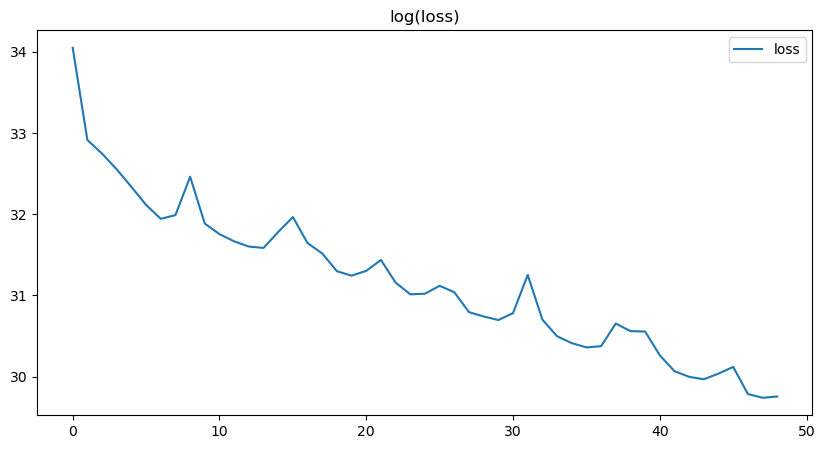

In [78]:
# Plot loss
plt.figure(figsize=(10, 5))
plt.plot(epoch_loss[0:-1], label='loss')
plt.title('log(loss)')
plt.legend()
plt.show()

# Sampling

(-5.0, 5.0)

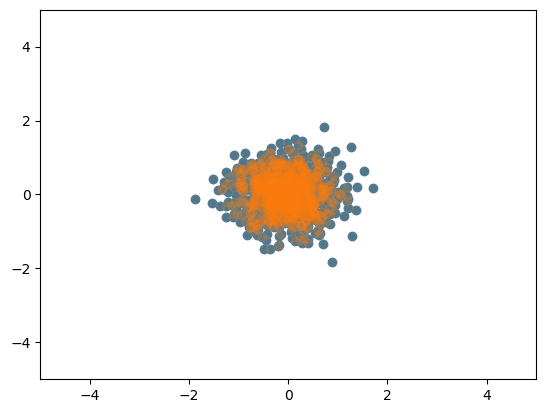

In [177]:
#model.load_state_dict(torch.load('../testing/realNVP_2026-06-22 13:14:29.300092.pth', weights_only=True))
model.eval()

x0 = base.sample(1000)
x1 = model.forward(x0)
log_x1 = model.log_prob(x0)
x0_valid = x0[~torch.isnan(log_x1)]
x0_valid.shape

x0_from_data = model.inverse(attenu_latent)
x0_from_x1 = model.inverse(model.forward(x0))
x0 = x0.detach().numpy()
x1 = x1.detach().numpy()
x0_from_data = x0_from_data.detach().numpy()
x0_from_x1 = x0_from_x1.detach().numpy()

plt.scatter(x0[:, 0], x0[:, 1])
plt.scatter(x0_from_x1[:, 0], x0_from_x1[:, 1], alpha = 0.2)
plt.xlim((-5, 5))
plt.ylim((-5, 5))

/Users/leo/miniconda3/envs/venv_pytorch/lib/python3.14/site-packages/sklearn/base.py:525: InconsistentVersionWarning: Trying to unpickle estimator PCA from version 1.8.0 when using version 1.9.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


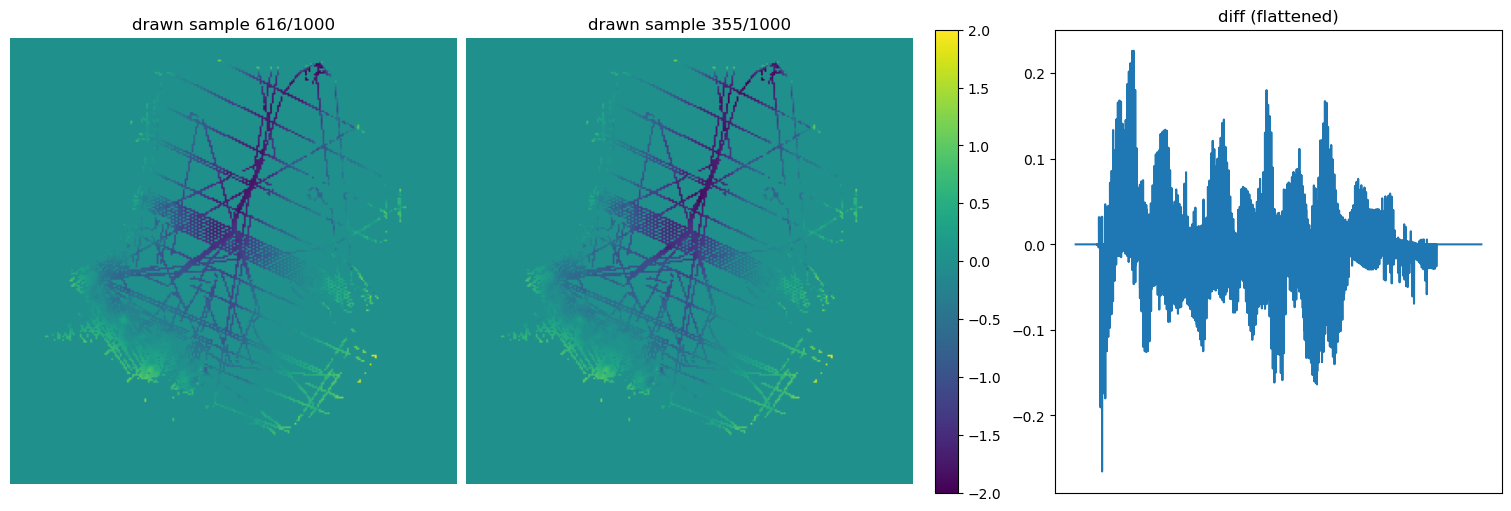

In [145]:
attenu_pca = joblib.load('../testing/attenu_pca2026-06-12 15:13:52.857122.pkl')
attenu_samples = attenu_pca.inverse_transform(x0_valid.detach().numpy())
attenu_samples = attenu_samples.reshape((attenu_samples.shape[0], 256, 256))

figs, axs = plt.subplots(1,3, figsize = (15, 5), layout="constrained")

vmin = -2
vmax = 2

rng = np.random.default_rng()
idx = rng.choice(attenu_samples.shape[0], size=2, replace=False)

axs[0].imshow(attenu_samples[idx[0], :, :], vmin = vmin, vmax = vmax)
axs[0].set_title(f"drawn sample {idx[0]}/{attenu_samples.shape[0]}")
axs[0].set_axis_off()

im1 = axs[1].imshow(attenu_samples[idx[1], :, :], vmin = vmin, vmax = vmax)
axs[1].set_title(f"drawn sample {idx[1]}/{attenu_samples.shape[0]}")
axs[1].set_axis_off()
plt.colorbar(im1)

axs[2].plot((attenu_samples[idx[0], :, :] - attenu_samples[idx[1], :, :]).flatten())
axs[2].set_title("diff (flattened)")
axs[2].xaxis.set_visible(False)

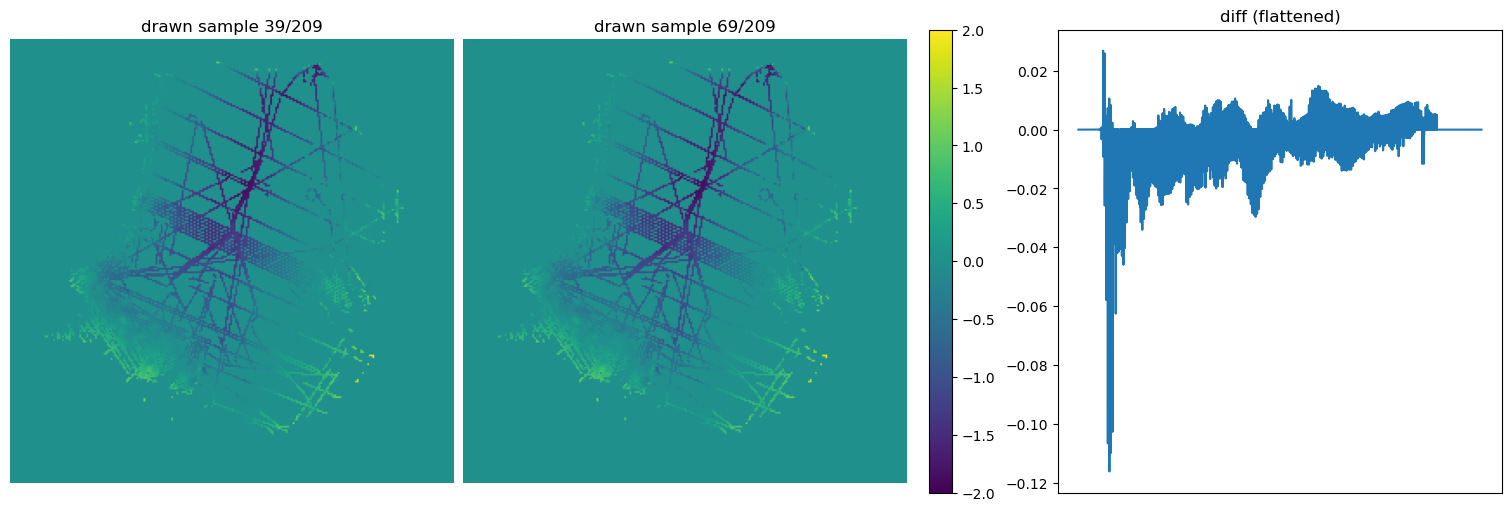

In [146]:
# compare variance to ensemble samples

attenu_ensemble_samples = attenu_pca.inverse_transform(attenu_latent.detach().numpy())
attenu_ensemble_samples = attenu_ensemble_samples.reshape((attenu_ensemble_samples.shape[0], 256, 256))
figs, axs = plt.subplots(1,3, figsize = (15, 5), layout="constrained")

vmin = -2
vmax = 2

rng = np.random.default_rng()
idx = rng.choice(attenu_ensemble_samples.shape[0], size=2, replace=False)

axs[0].imshow(attenu_ensemble_samples[idx[0], :, :], vmin = vmin, vmax = vmax)
axs[0].set_title(f"drawn sample {idx[0]}/{attenu_ensemble_samples.shape[0]}")
axs[0].set_axis_off()

im1 = axs[1].imshow(attenu_ensemble_samples[idx[1], :, :], vmin = vmin, vmax = vmax)
axs[1].set_title(f"drawn sample {idx[1]}/{attenu_ensemble_samples.shape[0]}")
axs[1].set_axis_off()
plt.colorbar(im1)

axs[2].plot((attenu_ensemble_samples[idx[0], :, :] - attenu_ensemble_samples[idx[1], :, :]).flatten())
axs[2].set_title("diff (flattened)")
axs[2].xaxis.set_visible(False)

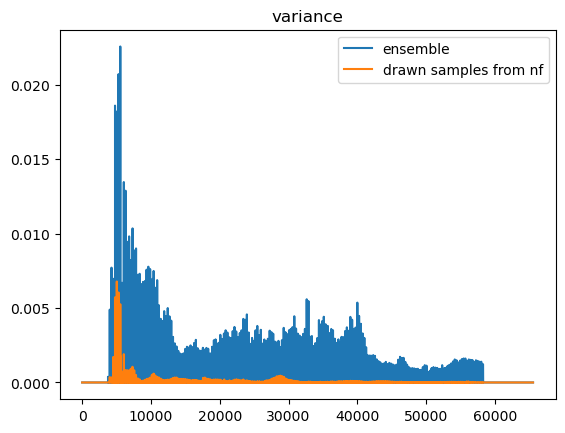

In [169]:
var_attenu_ensemble_samples = np.var(attenu_ensemble_samples, axis = 0)
var_attenu_samples = np.var(attenu_samples, axis = 0)

plt.plot(var_attenu_samples.flatten(), label = 'ensemble')
plt.plot(var_attenu_ensemble_samples.flatten(), label = 'drawn samples from nf')
plt.title("variance")
plt.legend()

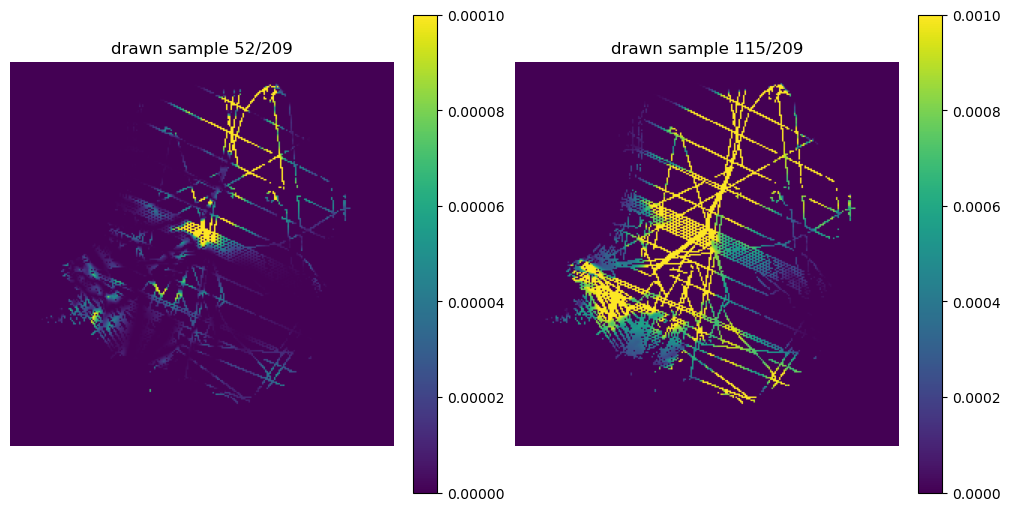

In [ ]:
figs, axs = plt.subplots(1,2, figsize = (10, 5), layout="constrained")

im0 = axs[0].imshow(var_attenu_ensemble_samples, vmin = 0, vmax = 1e-4)
axs[0].set_title(f"variance: ensemble")
axs[0].set_axis_off()
plt.colorbar(im0)

im1 = axs[1].imshow(var_attenu_samples, vmin = 0, vmax = 1e-3)
axs[1].set_title(f"variance: samples drawn from nf")
axs[1].set_axis_off()
plt.colorbar(im1)
